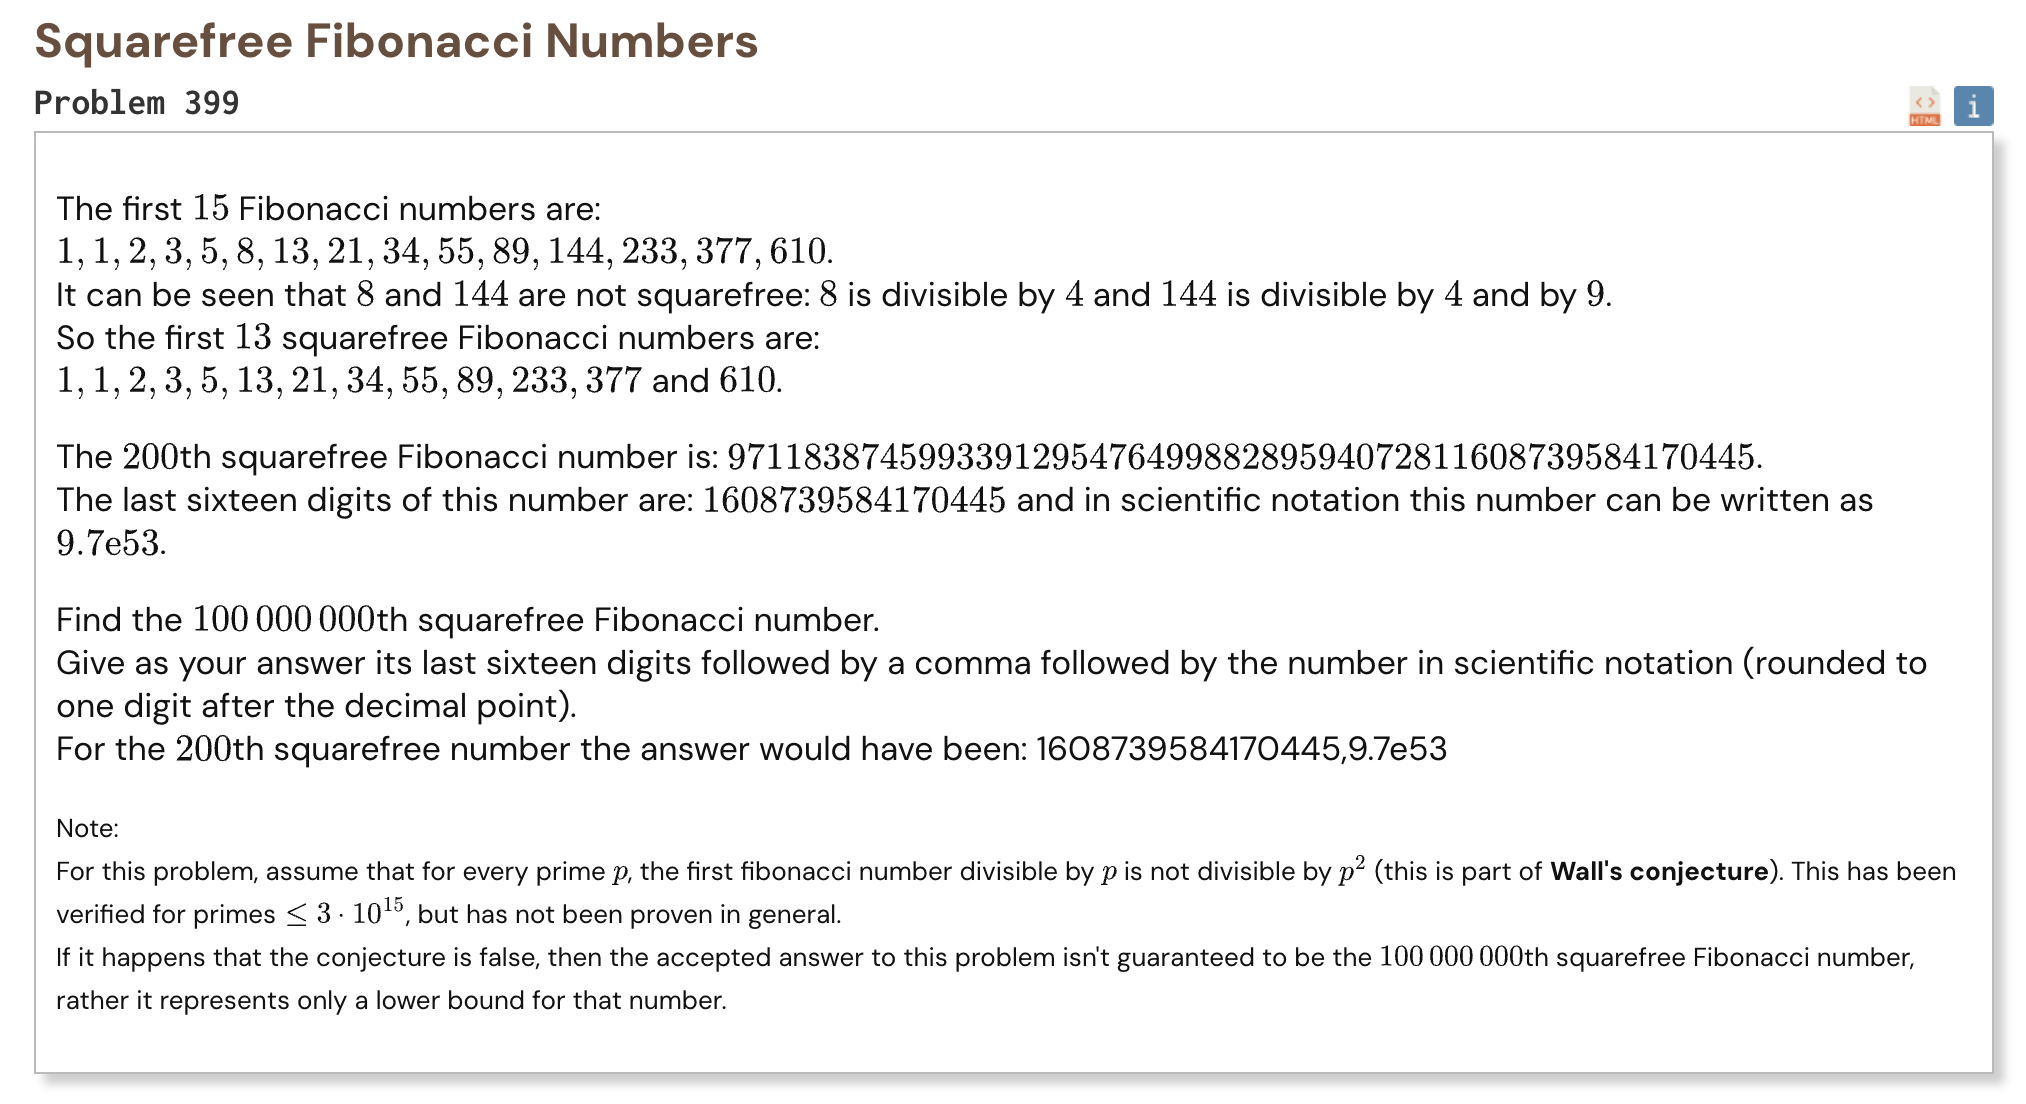

## Initial approach

-   a Fibonacci number is not squarefree when its index is divisible by the first index containing some prime square
-   under the given assumption this forbidden index is p times the first index where Fibonacci is divisible by p
-   find that first index by reducing a divisor of p minus or plus one
-   use inclusion exclusion over all relevant forbidden indices
-   group subsets that produce the same least common multiple
-   binary search for the index of the one hundred millionth valid Fibonacci number
-   use fast doubling for the last sixteen digits and logarithms for scientific notation
-   use collections defaultdict to combine equal least common multiples easily

In [1]:
import math
import sys
from collections import defaultdict


MOD = 10 ** 16


def fibonacci_mod(n, modulus):
    a, b = 0, 1

    for bit in range(n.bit_length() - 1, -1, -1):
        c = a * ((2 * b - a) % modulus) % modulus
        d = (a * a + b * b) % modulus

        if (n >> bit) & 1:
            a, b = d, (c + d) % modulus
        else:
            a, b = c, d

    return a


def primes_up_to(limit):
    sieve = bytearray(b"\x01") * (limit + 1)
    sieve[0:2] = b"\x00\x00"

    for value in range(2, math.isqrt(limit) + 1):
        if sieve[value]:
            start = value * value
            count = (limit - start) // value + 1
            sieve[start:limit + 1:value] = b"\x00" * count

    return [
        value
        for value in range(2, limit + 1)
        if sieve[value]
    ]


def unique_prime_factors(value, primes):
    factors = []

    for prime in primes:
        if prime * prime > value:
            break

        if value % prime == 0:
            factors.append(prime)

            while value % prime == 0:
                value //= prime

    if value > 1:
        factors.append(value)

    return factors


def fibonacci_rank(prime, small_primes):
    if prime == 2:
        return 3

    if prime == 5:
        return 5

    symbol = pow(5, (prime - 1) // 2, prime)
    candidate = prime - 1 if symbol == 1 else prime + 1
    rank = candidate

    for factor in unique_prime_factors(candidate, small_primes):
        while (
            rank % factor == 0
            and fibonacci_mod(rank // factor, prime) == 0
        ):
            rank //= factor

    return rank


def prime_limit_for_indices(index_limit):
    fibonacci_previous = 0
    fibonacci_current = 1
    result = 0

    for index in range(1, 200):
        fibonacci_previous, fibonacci_current = (
            fibonacci_current,
            fibonacci_previous + fibonacci_current
        )

        candidate = min(
            fibonacci_previous,
            index_limit // index
        )

        result = max(result, candidate)

        if index > 60 and index_limit // index <= result:
            break

    return result


def forbidden_indices(index_limit):
    prime_limit = prime_limit_for_indices(index_limit)
    primes = primes_up_to(prime_limit)
    small_primes = primes_up_to(math.isqrt(prime_limit + 1) + 1)

    indices = []

    for prime in primes:
        rank = fibonacci_rank(prime, small_primes)
        forbidden = prime * rank

        if forbidden <= index_limit:
            indices.append(forbidden)

    indices.sort()
    filtered = []

    for forbidden in indices:
        if all(forbidden % previous != 0 for previous in filtered):
            filtered.append(forbidden)

    return filtered


def inclusion_exclusion(indices, index_limit):
    coefficients = defaultdict(int)
    coefficients[1] = 1

    sys.setrecursionlimit(10000)

    def search(start, current_lcm, sign):
        for position in range(start, len(indices)):
            value = indices[position]

            if current_lcm % value == 0:
                continue

            next_lcm = math.lcm(current_lcm, value)

            if next_lcm > index_limit:
                continue

            next_sign = -sign
            coefficients[next_lcm] += next_sign

            search(
                position + 1,
                next_lcm,
                next_sign
            )

    search(0, 1, 1)

    return [
        (lcm_value, coefficient)
        for lcm_value, coefficient in coefficients.items()
        if coefficient
    ]


def count_squarefree_fibonacci_indices(limit, coefficients):
    return sum(
        coefficient * (limit // lcm_value)
        for lcm_value, coefficient in coefficients
    )


def find_index(target, index_limit, coefficients):
    low = 1
    high = index_limit

    while low < high:
        middle = (low + high) // 2

        if (
            count_squarefree_fibonacci_indices(
                middle,
                coefficients
            )
            >= target
        ):
            high = middle
        else:
            low = middle + 1

    return low


def format_answer(index):
    last_digits = fibonacci_mod(index, MOD)

    golden_ratio = (1 + math.sqrt(5)) / 2
    logarithm = (
        index * math.log10(golden_ratio)
        - math.log10(5) / 2
    )

    exponent = math.floor(logarithm)
    leading = 10 ** (logarithm - exponent)
    leading = round(leading, 1)

    if leading >= 10:
        leading = 1.0
        exponent += 1

    return f"{last_digits:016d},{leading:.1f}e{exponent}"


def solve():
    target = 100_000_000
    index_limit = 200_000_000

    indices = forbidden_indices(index_limit)
    coefficients = inclusion_exclusion(
        indices,
        index_limit
    )

    index = find_index(
        target,
        index_limit,
        coefficients
    )

    return format_answer(index)

In [2]:
%%time
result = solve()
print("Result:", result)

Result: 1508395636674243,6.5e27330467
CPU times: user 16.3 s, sys: 136 ms, total: 16.5 s
Wall time: 16.6 s
